In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.preprocessing import MinMaxScaler
import warnings
import glob
import os
import collections.abc
from tqdm.auto import tqdm # Import tqdm for progress bar
import matplotlib.pyplot as plt # Added for plotting
import seaborn as sns # Added for plotting aesthetics

In [2]:
DATA_DIR = "." 
PATH_BANK_HOLIDAYS = os.path.join(DATA_DIR, "uk_bank_holidays.csv")
PATH_INFO_HOUSEHOLDS = os.path.join(DATA_DIR, "informations_households.csv")
PATH_WEATHER = os.path.join(DATA_DIR, "weather_daily_darksky.csv")
OUTPUT_CSV_PATH = os.path.join(DATA_DIR, "merged_predictions_sample.csv")
# Pattern for daily energy block files
DAILY_DATA_FOLDER = "daily_dataset"
DAILY_DATA_PATTERN = os.path.join(DATA_DIR, DAILY_DATA_FOLDER, "block_*.csv")

In [3]:
# Columns to use for weather features and normalization
WEATHER_FEATURES = [
    "temperatureMax", "temperatureMin", "dewPoint", "humidity",
    "cloudCover", "windSpeed", "pressure"]
# Columns to drop NaNs from in the respective dataframes
DAILY_DATASET_NAN_DROP_COLS = ['energy_median', 'energy_mean', 'energy_max', 'energy_sum']
WEATHER_NAN_DROP_COLS = WEATHER_FEATURES # Ensure we drop NaNs for all features used

In [4]:
# --- ** Sampling Configuration (for faster testing) ** ---
RUN_ON_SAMPLE = True # Set to False to run on the full dataset
SAMPLE_SIZE = 50000  # Number of rows to process if RUN_ON_SAMPLE is True
SAMPLING_METHOD = 'head' # 'head' for first N rows, 'random' for random sample
SCATTER_PLOT_SAMPLE_SIZE = 5000 # Number of points for the scatter plot (to keep it readable)
LINE_PLOT_DAYS = 90 # Number of days to show in the line plot for one household

In [5]:
# --- 1. Load Datasets ---
print("Loading datasets...")
try:
    # Load single files
    # df_acorn_details = pd.read_csv(PATH_ACORN_DETAILS, encoding='latin-1') # REMOVED
    df_bank_holidays = pd.read_csv(PATH_BANK_HOLIDAYS)
    df_info_households = pd.read_csv(PATH_INFO_HOUSEHOLDS)
    df_weather = pd.read_csv(PATH_WEATHER)

    # --- Load and combine multiple daily block files ---
    print(f"Looking for daily energy files matching: {DAILY_DATA_PATTERN}")
    block_files = glob.glob(DAILY_DATA_PATTERN)
    if not block_files:
        print(f"Error: No files found matching the pattern '{DAILY_DATA_PATTERN}'. Please check the file names and directory structure.")
        exit()

    print(f"Found {len(block_files)} daily energy block files. Loading and concatenating...")
    # Use tqdm for loading progress if many files
    all_daily_data = [pd.read_csv(f) for f in tqdm(block_files, desc="Loading block files")]
    # Filter out potentially empty or invalid dataframes after reading
    all_daily_data = [df for df in all_daily_data if not df.empty and all(col in df.columns for col in ['LCLid', 'day'] + DAILY_DATASET_NAN_DROP_COLS)]

    if not all_daily_data:
        print("Error: No valid daily block files could be loaded or processed. Exiting.")
        exit()

    # Concatenate all block dataframes into one
    df_daily_dataset = pd.concat(all_daily_data, ignore_index=True)
    print(f"Combined daily dataset loaded successfully ({len(df_daily_dataset)} rows).")
    # --- End of multi-file loading ---

    print("Core datasets loaded successfully.") # Updated message

except FileNotFoundError as e:
    print(f"Error loading file: {e}. Please ensure required CSV files are in the correct directory '{DATA_DIR}' and the '{DAILY_DATA_FOLDER}' subfolder exists.")
    exit() # Exit if essential files are missing
except Exception as e:
    print(f"An unexpected error occurred during file loading: {e}")
    exit()

Loading datasets...
Looking for daily energy files matching: .\daily_dataset\block_*.csv
Found 112 daily energy block files. Loading and concatenating...


Loading block files:   0%|          | 0/112 [00:00<?, ?it/s]

Combined daily dataset loaded successfully (3510433 rows).
Core datasets loaded successfully.


In [6]:
# --- 2. Initial Data Inspection (Optional but Recommended) ---
print("\nInitial Data Info:")
print("Combined Daily Dataset Info:")
df_daily_dataset.info() # Show info for the combined dataframe
print("\nWeather Dataset Info:")
df_weather.info()
# print("\nAcorn Details Info:") # REMOVED
# df_acorn_details.info()        # REMOVED
print("\nHousehold Info:")
df_info_households.info() # Check column names here


Initial Data Info:
Combined Daily Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3510433 entries, 0 to 3510432
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   LCLid          object 
 1   day            object 
 2   energy_median  float64
 3   energy_mean    float64
 4   energy_max     float64
 5   energy_count   int64  
 6   energy_std     float64
 7   energy_sum     float64
 8   energy_min     float64
dtypes: float64(6), int64(1), object(2)
memory usage: 241.0+ MB

Weather Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 882 entries, 0 to 881
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   temperatureMax               882 non-null    float64
 1   temperatureMaxTime           882 non-null    object 
 2   windBearing                  882 non-null    int64  
 3   icon                         882 non-null   

In [7]:
# --- 3. Handle Missing Values ---
print("\nHandling missing values...")
# Drop rows with missing energy data from the combined dataset
initial_daily_rows = len(df_daily_dataset)
df_daily_dataset.dropna(subset=DAILY_DATASET_NAN_DROP_COLS, inplace=True)
print(f"Dropped {initial_daily_rows - len(df_daily_dataset)} rows with missing energy data.")

# Drop rows with missing key weather data
initial_weather_rows = len(df_weather)
# Ensure 'cloudCover' exists before trying to drop NaNs based on it
if 'cloudCover' not in df_weather.columns:
    print("Warning: 'cloudCover' column not found in weather data. Removing from NaN check.")
    WEATHER_NAN_DROP_COLS = [col for col in WEATHER_NAN_DROP_COLS if col != 'cloudCover']
    WEATHER_FEATURES = [col for col in WEATHER_FEATURES if col != 'cloudCover'] # Also remove from features

# Make sure WEATHER_NAN_DROP_COLS only contains columns actually present in df_weather
valid_weather_nan_drop_cols = [col for col in WEATHER_NAN_DROP_COLS if col in df_weather.columns]
if len(valid_weather_nan_drop_cols) < len(WEATHER_NAN_DROP_COLS):
    print(f"Warning: Some weather columns specified for NaN drop were not found: {set(WEATHER_NAN_DROP_COLS) - set(valid_weather_nan_drop_cols)}")

if valid_weather_nan_drop_cols: # Only drop if there are valid columns to check
    df_weather.dropna(subset=valid_weather_nan_drop_cols, inplace=True)
    print(f"Dropped {initial_weather_rows - len(df_weather)} rows with missing weather data.")
else:
    print("Skipping weather NaN drop as no valid key columns were found.")


Handling missing values...
Dropped 30 rows with missing energy data.
Dropped 1 rows with missing weather data.


In [8]:
# --- 4. Date Conversions and Holiday Flag ---
print("\nProcessing dates and holidays...")
# Convert weather 'time' to 'day' (date only)
if 'time' in df_weather.columns and pd.api.types.is_numeric_dtype(df_weather['time']):
    df_weather['time'] = pd.to_datetime(df_weather['time'], unit='s', errors='coerce')
elif 'time' in df_weather.columns:
     df_weather['time'] = pd.to_datetime(df_weather['time'], errors='coerce')
else:
    print("Warning: 'time' column not found in weather data.")
df_weather.dropna(subset=['time'], inplace=True)
df_weather['day'] = df_weather['time'].dt.normalize()

# Convert combined daily_dataset 'day' to datetime
df_daily_dataset['day'] = pd.to_datetime(df_daily_dataset['day'], errors='coerce')
df_daily_dataset.dropna(subset=['day'], inplace=True)

# Prepare bank holidays data
holiday_col_name = 'Bank holidays'
if holiday_col_name not in df_bank_holidays.columns:
    potential_date_cols = [col for col in df_bank_holidays.columns if 'date' in col.lower()]
    if potential_date_cols: holiday_col_name = potential_date_cols[0]
    else: print(f"Error: Date column not found in {PATH_BANK_HOLIDAYS}."); exit()
df_bank_holidays.rename(columns={holiday_col_name: 'day'}, inplace=True)
try: df_bank_holidays['day'] = pd.to_datetime(df_bank_holidays['day'], format='%Y-%m-%d', errors='coerce')
except ValueError: df_bank_holidays['day'] = pd.to_datetime(df_bank_holidays['day'], errors='coerce')
df_bank_holidays.dropna(subset=['day'], inplace=True)
df_bank_holidays['is_holiday'] = 1
df_bank_holidays = df_bank_holidays[['day', 'is_holiday']].drop_duplicates(subset='day')
print("Date conversions complete.")


Processing dates and holidays...
Date conversions complete.


In [9]:
# --- 5. Merge Datasets ---
print("\nMerging datasets...")
# Select relevant weather columns and remove duplicate days
weather_cols_to_merge = ['day'] + [col for col in WEATHER_FEATURES if col in df_weather.columns]
df_weather_daily = df_weather[weather_cols_to_merge].drop_duplicates(subset='day', keep='first')

# Merge daily data with weather
df_merged = pd.merge(df_daily_dataset, df_weather_daily, on='day', how='inner')
print(f"Rows after merging with weather: {len(df_merged)}")

# Merge with bank holidays
df_merged = pd.merge(df_merged, df_bank_holidays, on='day', how='left')
df_merged['is_holiday'] = df_merged['is_holiday'].fillna(0).astype(int)

# Merge with household information
household_cols_to_merge = ['LCLid', 'stdorToU', 'Acorn', 'Acorn_grouped', 'file']
valid_household_cols = [col for col in household_cols_to_merge if col in df_info_households.columns]
if 'LCLid' in df_merged.columns and 'LCLid' in valid_household_cols:
    if 'LCLid' not in valid_household_cols: valid_household_cols.append('LCLid')
    df_merged = pd.merge(df_merged, df_info_households[valid_household_cols], on='LCLid', how='left')
    print(f"Rows after merging with household info: {len(df_merged)}")
else:
    print("Warning: Could not merge household info ('LCLid' missing?).")

if df_merged.empty: print("\nError: DataFrame empty after merging."); exit()
print(f"\nTotal rows in final merged DataFrame: {len(df_merged)}")
print("Columns:", df_merged.columns.tolist())

# --- ** Apply Sampling If Enabled ** ---
if RUN_ON_SAMPLE:
    print(f"\n--- Running on a sample of the data ({SAMPLING_METHOD} method) ---")
    if SAMPLING_METHOD == 'head':
        if SAMPLE_SIZE >= len(df_merged):
             print(f"Sample size ({SAMPLE_SIZE}) is >= total rows ({len(df_merged)}). Running on full data.")
        else:
             print(f"Selecting first {SAMPLE_SIZE} rows.")
             df_merged = df_merged.head(SAMPLE_SIZE).copy()
    elif SAMPLING_METHOD == 'random':
        if SAMPLE_SIZE >= len(df_merged):
             print(f"Sample size ({SAMPLE_SIZE}) is >= total rows ({len(df_merged)}). Running on full data.")
        else:
             print(f"Selecting random sample of {SAMPLE_SIZE} rows.")
             df_merged = df_merged.sample(n=SAMPLE_SIZE, random_state=42).copy() # Use random_state for reproducibility
    else:
        print(f"Warning: Unknown SAMPLING_METHOD '{SAMPLING_METHOD}'. Running on full data.")

    print(f"Sampled DataFrame size: {len(df_merged)} rows")
    OUTPUT_CSV_PATH = os.path.join(DATA_DIR, f"merged_predictions_sample_{SAMPLE_SIZE}.csv") # Adjust output name for sample
    print(f"Output will be saved to: {OUTPUT_CSV_PATH}")


Merging datasets...
Rows after merging with weather: 3494590
Rows after merging with household info: 3494590

Total rows in final merged DataFrame: 3494590
Columns: ['LCLid', 'day', 'energy_median', 'energy_mean', 'energy_max', 'energy_count', 'energy_std', 'energy_sum', 'energy_min', 'temperatureMax', 'temperatureMin', 'dewPoint', 'humidity', 'cloudCover', 'windSpeed', 'pressure', 'is_holiday', 'stdorToU', 'Acorn', 'Acorn_grouped', 'file']

--- Running on a sample of the data (head method) ---
Selecting first 50000 rows.
Sampled DataFrame size: 50000 rows
Output will be saved to: .\merged_predictions_sample_50000.csv


In [10]:
# --- 6. Normalize Relevant Columns for Fuzzy Logic ---
print("\nNormalizing features...")
columns_to_normalize = [col for col in WEATHER_FEATURES if col in df_merged.columns]
print(f"Columns to normalize: {columns_to_normalize}")

if not columns_to_normalize: print("Error: No columns for normalization."); exit()

# Convert to numeric
for col in columns_to_normalize:
    df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce')

# Recalculate columns to normalize after coercion
columns_to_normalize = [col for col in columns_to_normalize if col in df_merged.columns and pd.api.types.is_numeric_dtype(df_merged[col])]
print(f"Actual columns being normalized: {columns_to_normalize}")

# Fill NaNs with median
if columns_to_normalize:
    medians = df_merged[columns_to_normalize].median()
    for col in columns_to_normalize:
        if df_merged[col].isnull().any():
             if col in medians and pd.notna(medians[col]):
                 df_merged[col].fillna(medians[col], inplace=True)
             else:
                 print(f"Warning: Could not fill NaNs in '{col}'.")

    # Check for NaNs/Infs before scaling
    nan_check = df_merged[columns_to_normalize].isnull().sum().sum()
    inf_check = np.isinf(df_merged[columns_to_normalize]).sum().sum()
    if nan_check > 0 or inf_check > 0:
        print(f"ERROR: {nan_check} NaNs / {inf_check} Infs detected before scaling! Dropping rows.")
        df_merged.dropna(subset=columns_to_normalize, inplace=True)

    # Apply scaling
    weather_scaler = MinMaxScaler() # Rename scaler for clarity
    df_merged[columns_to_normalize] = weather_scaler.fit_transform(df_merged[columns_to_normalize])

    # Check for NaNs/Infs after scaling
    nan_check_after = df_merged[columns_to_normalize].isnull().sum().sum()
    inf_check_after = np.isinf(df_merged[columns_to_normalize]).sum().sum()
    if nan_check_after > 0 or inf_check_after > 0:
        print(f"ERROR: {nan_check_after} NaNs / {inf_check_after} Infs detected after scaling! Dropping rows.")
        df_merged.dropna(subset=columns_to_normalize, inplace=True)

    print("Normalization complete.")
else:
    print("Skipping normalization as no valid numeric columns were found.")


Normalizing features...
Columns to normalize: ['temperatureMax', 'temperatureMin', 'dewPoint', 'humidity', 'cloudCover', 'windSpeed', 'pressure']
Actual columns being normalized: ['temperatureMax', 'temperatureMin', 'dewPoint', 'humidity', 'cloudCover', 'windSpeed', 'pressure']
Normalization complete.


In [11]:
# --- 7. Define Fuzzy Variables (Antecedents) and Output (Consequent) ---
print("\nDefining fuzzy variables...")
universe = np.arange(-0.01, 1.02, 0.01) # Slightly extended universe

antecedents = {}
# Define antecedents ONLY for columns that were successfully normalized
for col in columns_to_normalize:
     antecedents[col] = ctrl.Antecedent(universe, col)
     # print(f"Defined antecedent: {col}") # Reduce verbosity


if not antecedents: print("Error: No antecedents defined."); exit()

# Consequent
predictedEnergy = ctrl.Consequent(universe, 'predictedEnergy')
print(f"Fuzzy antecedents defined: {list(antecedents.keys())}")


Defining fuzzy variables...
Fuzzy antecedents defined: ['temperatureMax', 'temperatureMin', 'dewPoint', 'humidity', 'cloudCover', 'windSpeed', 'pressure']


In [12]:
# --- 8. Define Membership Functions ---
print("Defining membership functions...")
# *** Using wider, overlapping triangular MFs ***
# Points defining the triangles: [left_base, peak, right_base]
low_mf_tri = [-0.01, 0.15, 0.45]  # Peaks at 0.15, covers roughly 0 to 0.45
med_mf_tri = [0.15, 0.5, 0.85]   # Peaks at 0.5, covers roughly 0.15 to 0.85
high_mf_tri = [0.55, 0.85, 1.01] # Peaks at 0.85, covers roughly 0.55 to 1

for name, var in antecedents.items():
    var['low'] = fuzz.trimf(var.universe, low_mf_tri)
    var['medium'] = fuzz.trimf(var.universe, med_mf_tri)
    var['high'] = fuzz.trimf(var.universe, high_mf_tri)

predictedEnergy['low'] = fuzz.trimf(predictedEnergy.universe, low_mf_tri)
predictedEnergy['medium'] = fuzz.trimf(predictedEnergy.universe, med_mf_tri)
predictedEnergy['high'] = fuzz.trimf(predictedEnergy.universe, high_mf_tri)
print("Membership functions defined using triangular functions.")

Defining membership functions...
Membership functions defined using triangular functions.


In [13]:
# --- 9. Create Fuzzy Rules ---
# *** Using ORIGINAL RULESET + Default Rule ***
print("Defining ORIGINAL fuzzy rules + Default Rule...")
rules = []
antecedents_in_rules = set() # Keep track of antecedents used

# Original Rules
# Rule 1: If temperature is high AND humidity is low, energy is high (AC?)
if 'temperatureMax' in antecedents and 'humidity' in antecedents:
    rules.append(ctrl.Rule(antecedents['temperatureMax']['high'] & antecedents['humidity']['low'], predictedEnergy['high']))
    antecedents_in_rules.update(['temperatureMax', 'humidity'])

# Rule 2: If temperature is low AND cloud cover is high, energy is medium/high (heating/lights?)
if 'temperatureMin' in antecedents and 'cloudCover' in antecedents:
     rules.append(ctrl.Rule(antecedents['temperatureMin']['low'] & antecedents['cloudCover']['high'], predictedEnergy['high']))
     antecedents_in_rules.update(['temperatureMin', 'cloudCover'])
elif 'temperatureMin' in antecedents and 'humidity' in antecedents: # Alternative if cloudCover is not available
     rules.append(ctrl.Rule(antecedents['temperatureMin']['low'] & antecedents['humidity']['high'], predictedEnergy['medium']))
     antecedents_in_rules.update(['temperatureMin', 'humidity'])

# Rule 3: If humidity is high AND wind speed is low, energy is medium (stagnant, humid day?)
if 'humidity' in antecedents and 'windSpeed' in antecedents:
    rules.append(ctrl.Rule(antecedents['humidity']['high'] & antecedents['windSpeed']['low'], predictedEnergy['medium']))
    antecedents_in_rules.update(['humidity', 'windSpeed'])

# Rule 5: Cold and windy -> High energy (heating)
if 'temperatureMin' in antecedents and 'windSpeed' in antecedents:
    rules.append(ctrl.Rule(antecedents['temperatureMin']['low'] & antecedents['windSpeed']['high'], predictedEnergy['high']))
    antecedents_in_rules.update(['temperatureMin', 'windSpeed'])

# Rule 6: Pleasant temperature -> Low energy
if 'temperatureMax' in antecedents and 'temperatureMin' in antecedents:
     rules.append(ctrl.Rule(antecedents['temperatureMax']['medium'] & antecedents['temperatureMin']['medium'], predictedEnergy['low']))
     antecedents_in_rules.update(['temperatureMax', 'temperatureMin'])

# Rule 7: Hot and Humid -> High energy (AC)
if 'temperatureMax' in antecedents and 'humidity' in antecedents:
    rules.append(ctrl.Rule(antecedents['temperatureMax']['high'] & antecedents['humidity']['high'], predictedEnergy['high']))
    antecedents_in_rules.update(['temperatureMax', 'humidity'])

# Rule 8: Low Pressure (often stormy) -> Medium Energy? (People stay indoors?)
if 'pressure' in antecedents:
    rules.append(ctrl.Rule(antecedents['pressure']['low'], predictedEnergy['medium']))
    antecedents_in_rules.add('pressure')

# *** Default Rule: Added to ensure some output ***
if 'temperatureMax' in antecedents: # Use any available antecedent
     always_true_condition = (antecedents['temperatureMax']['low'] |
                              antecedents['temperatureMax']['medium'] |
                              antecedents['temperatureMax']['high'])
     default_rule = ctrl.Rule(always_true_condition, predictedEnergy['medium'])
     rules.append(default_rule)
     print("Added a default rule (output: medium).")


if not rules: print("Error: No valid rules created."); exit()
print(f"Defined {len(rules)} fuzzy rules using antecedents: {antecedents_in_rules}")

Defining ORIGINAL fuzzy rules + Default Rule...
Added a default rule (output: medium).
Defined 8 fuzzy rules using antecedents: {'pressure', 'cloudCover', 'temperatureMin', 'windSpeed', 'humidity', 'temperatureMax'}


In [14]:
# --- 10. Create Fuzzy Control System and Simulation ---
print("Creating fuzzy control system and simulation...")
try:
    energy_ctrl = ctrl.ControlSystem(rules=rules)
    predictedEnergy.defuzzify_method = 'centroid' # Set defuzz method
    # Create the simulation object ONCE here
    energy_simulation = ctrl.ControlSystemSimulation(energy_ctrl)
    print("Control system and simulation created.")

except Exception as e:
    print(f"Error creating control system or simulation: {e}")
    exit()

Creating fuzzy control system and simulation...
Control system and simulation created.


In [15]:
# --- 11. Run Predictions ---
print("\n--- Running Manual Simulation Test ---")
try:
    # Use the globally created simulation object
    # Set inputs based on ALL defined antecedents
    test_inputs = {key: 0.5 for key in antecedents.keys()}
    print(f"Manual test inputs: {test_inputs}")

    energy_simulation.reset() # Reset before test

    # Directly set inputs without checking energy_simulation.inputs
    for key, value in test_inputs.items():
        try:
            # Use the input setter directly
            energy_simulation.input[key] = value
        except ValueError:
             # This might happen if an antecedent was defined but somehow not included in the control system
             print(f"Warning (Manual Test): Could not set input for '{key}'. Skipping.")

    # Compute for manual inputs
    energy_simulation.compute()
    manual_output = energy_simulation.output['predictedEnergy']
    print(f"Manual test output (predictedEnergy): {manual_output}")
    if pd.isna(manual_output):
        print("MANUAL TEST FAILED: compute() returned NaN.")
    else:
        print("MANUAL TEST SUCCEEDED.")
except Exception as e:
    print(f"MANUAL TEST FAILED with exception: {type(e).__name__}: {e}")

print("--- End Manual Simulation Test ---\n")


print("Running fuzzy predictions on DataFrame (this may take a while)...")
prediction_errors = 0
error_log_count = 0
MAX_ERROR_LOGS = 5 # Log details for the first few errors only

# Map DataFrame column names to simulation input names (should match antecedent names now)
column_to_input_map = {key: key for key in antecedents.keys()}

def run_simulation(row):
    global prediction_errors, error_log_count
    # Use the globally defined simulation object, just reset it
    energy_simulation.reset()

    try:
        input_values_for_sim = {}

        # *** Iterate only over antecedents USED IN RULES ***
        # This avoids the ValueError for unused antecedents like 'dewPoint'
        for antecedent_key in antecedents_in_rules:
             df_col_name = column_to_input_map.get(antecedent_key)
             input_value = 0.5 # Default neutral value

             if df_col_name and df_col_name in row.index and pd.notna(row[df_col_name]):
                 clipped_value = max(0.0, min(1.0, row[df_col_name]))
                 if pd.notna(clipped_value): input_value = clipped_value
                 else: input_value = 0.5 # Fallback if clipping fails

             # Directly set input without checking energy_simulation.inputs
             try:
                  energy_simulation.input[antecedent_key] = input_value
                  input_values_for_sim[antecedent_key] = input_value # Log value used
             except ValueError:
                  # Log if setting fails (should only happen if antecedent_key is somehow wrong)
                  if error_log_count < MAX_ERROR_LOGS:
                      print(f"DEBUG (run_simulation): ValueError setting input for '{antecedent_key}'.")
                  # Continue without this input if setting failed, or return NaN immediately
                  # return np.nan # Option: fail prediction if any input fails


        # Compute the result
        energy_simulation.compute()
        output_dict = energy_simulation.output

        # Check if the key exists before trying to access it
        if predictedEnergy.label in output_dict:
             predicted_value = output_dict[predictedEnergy.label] # Access using the label
        else:
             # If the key is missing, log the details and return NaN
             prediction_errors += 1
             if error_log_count < MAX_ERROR_LOGS:
                  print(f"\n--- ERROR LOG {error_log_count + 1} (KeyError: '{predictedEnergy.label}') ---")
                  print(f"Output dictionary does not contain the key '{predictedEnergy.label}'.")
                  print(f"Output dictionary content: {output_dict}")
                  print(f"Input values passed to simulation: {input_values_for_sim}")
                  error_log_count += 1
             return np.nan


        # Check if the retrieved value is NaN (can happen if defuzz fails)
        if pd.isna(predicted_value):
             prediction_errors += 1
             if error_log_count < MAX_ERROR_LOGS:
                  print(f"\n--- ERROR LOG {error_log_count + 1} (compute returned NaN value) ---")
                  print(f"Input values passed to simulation: {input_values_for_sim}")
                  print(f"Output dictionary content: {output_dict}") # Print dict even if value is NaN
                  error_log_count += 1
             return np.nan
        return predicted_value

    except Exception as e:
        prediction_errors += 1
        if error_log_count < MAX_ERROR_LOGS:
             print(f"\n--- ERROR LOG {error_log_count + 1} (Exception) ---")
             print(f"Exception during simulation: {type(e).__name__}: {e}")
             try: print(f"Input values set before error: {input_values_for_sim}")
             except NameError: print("Could not retrieve input values before error.")
             error_log_count += 1
        return np.nan

# --- Apply simulation with progress bar ---
# Initialize tqdm for pandas
tqdm.pandas(desc="Applying fuzzy simulation")

print(f"Applying simulation to {len(df_merged)} rows...")
# Use .progress_apply() instead of .apply()
df_merged['predicted_energy'] = df_merged.progress_apply(run_simulation, axis=1)


if prediction_errors > 0:
    print(f"\nWarning: Encountered {prediction_errors} errors during fuzzy simulation.")
    nan_predictions = df_merged['predicted_energy'].isnull().sum()
    print(f"Total NaN values in 'predicted_energy' column: {nan_predictions}")
    if nan_predictions == len(df_merged):
        print("All predictions resulted in NaN. Check rules and inputs. See DEBUG logs.")
    elif nan_predictions > 0:
         # Option to fill remaining NaNs if some predictions worked
         predicted_median = df_merged['predicted_energy'].median()
         if pd.notna(predicted_median):
              df_merged['predicted_energy'].fillna(predicted_median, inplace=True)
              print(f"Filled {nan_predictions} NaN predictions with median value: {predicted_median:.4f}")
         else:
              print("Could not calculate median for predictions. Leaving NaNs.")

print("Predictions complete.")


--- Running Manual Simulation Test ---
Manual test inputs: {'temperatureMax': 0.5, 'temperatureMin': 0.5, 'dewPoint': 0.5, 'humidity': 0.5, 'cloudCover': 0.5, 'windSpeed': 0.5, 'pressure': 0.5}
Warning (Manual Test): Could not set input for 'dewPoint'. Skipping.
Manual test output (predictedEnergy): 0.3899897455020045
MANUAL TEST SUCCEEDED.
--- End Manual Simulation Test ---

Running fuzzy predictions on DataFrame (this may take a while)...
Applying simulation to 50000 rows...


Applying fuzzy simulation:   0%|          | 0/50000 [00:00<?, ?it/s]

Predictions complete.


In [16]:
# --- 11.5 Normalize Actual Energy for Comparison ---
print("\nNormalizing actual energy column for comparison...")
actual_energy_col = 'energy_sum' # Choose which actual energy column to compare
if actual_energy_col in df_merged.columns:
    # Ensure the column is numeric and handle potential NaNs before scaling
    df_merged[actual_energy_col] = pd.to_numeric(df_merged[actual_energy_col], errors='coerce')
    if df_merged[actual_energy_col].isnull().any():
        actual_median = df_merged[actual_energy_col].median()
        print(f"Filling {df_merged[actual_energy_col].isnull().sum()} NaNs in '{actual_energy_col}' with median ({actual_median}).")
        df_merged[actual_energy_col].fillna(actual_median, inplace=True)

    # Check for infinite values
    inf_check_actual = np.isinf(df_merged[actual_energy_col]).sum()
    if inf_check_actual > 0:
        print(f"ERROR: Found {inf_check_actual} infinite values in '{actual_energy_col}'. Replacing with NaN and filling with median.")
        df_merged[actual_energy_col].replace([np.inf, -np.inf], np.nan, inplace=True)
        actual_median = df_merged[actual_energy_col].median() # Recalculate median if needed
        df_merged[actual_energy_col].fillna(actual_median, inplace=True)


    # Apply MinMaxScaler to the actual energy column
    actual_energy_scaler = MinMaxScaler()
    # Reshape data for scaler (it expects a 2D array)
    actual_energy_values = df_merged[actual_energy_col].values.reshape(-1, 1)
    df_merged['actual_energy_normalized'] = actual_energy_scaler.fit_transform(actual_energy_values)
    print(f"'{actual_energy_col}' normalized and stored in 'actual_energy_normalized'.")
else:
    print(f"Warning: Column '{actual_energy_col}' not found. Cannot normalize actual energy.")
    df_merged['actual_energy_normalized'] = np.nan # Create column with NaNs


Normalizing actual energy column for comparison...
'energy_sum' normalized and stored in 'actual_energy_normalized'.



--- Performing Analysis ---

Correlation between predicted_energy and actual_energy_normalized: 0.0133

Generating scatter plot (sampling 5000 points)...


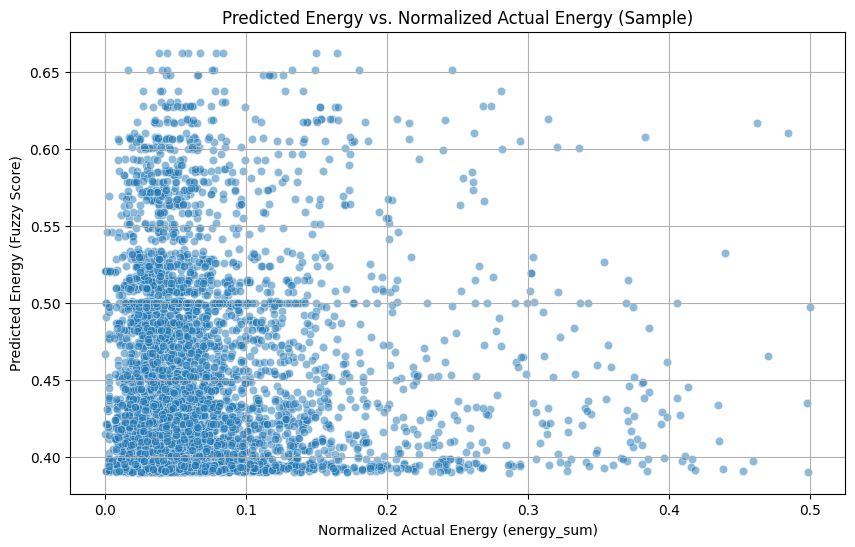

Scatter plot displayed.

Group Analysis by Acorn_grouped:
               actual_energy_normalized  predicted_energy
Acorn_grouped                                            
ACORN-                         0.043123          0.441944
Affluent                       0.073448          0.451466

Group Analysis by Month:
       actual_energy_normalized  predicted_energy
month                                            
1                      0.086246          0.464829
2                      0.080248          0.481074
3                      0.083234          0.514211
4                      0.074124          0.420686
5                      0.063892          0.413684
6                      0.060394          0.431716
7                      0.056704          0.504600
8                      0.058362          0.490638
9                      0.064903          0.431119
10                     0.071186          0.413339
11                     0.080796          0.424951
12                     0.087347   

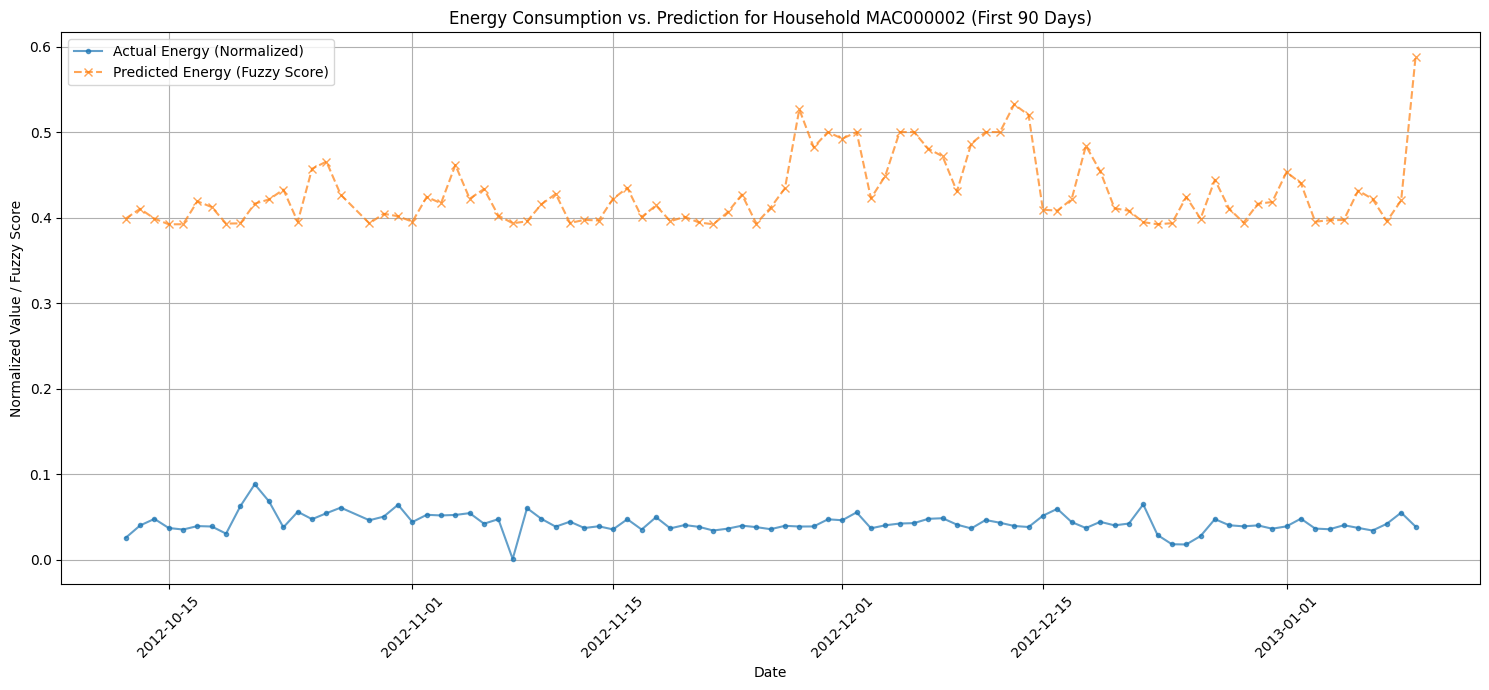

Line plot displayed.
--- Analysis Complete ---


In [17]:
# --- 12. Perform Analysis ---
print("\n--- Performing Analysis ---")

# Check if required columns exist and have non-NaN values
if 'predicted_energy' in df_merged.columns and \
   'actual_energy_normalized' in df_merged.columns and \
   df_merged['predicted_energy'].notna().any() and \
   df_merged['actual_energy_normalized'].notna().any():

    # 1. Correlation
    correlation = df_merged['predicted_energy'].corr(df_merged['actual_energy_normalized'])
    print(f"\nCorrelation between predicted_energy and actual_energy_normalized: {correlation:.4f}")

    # 2. Scatter Plot (using a sample for performance)
    print(f"\nGenerating scatter plot (sampling {SCATTER_PLOT_SAMPLE_SIZE} points)...")
    try:
        plot_sample_df = df_merged.sample(n=min(SCATTER_PLOT_SAMPLE_SIZE, len(df_merged)), random_state=42)
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=plot_sample_df, x='actual_energy_normalized', y='predicted_energy', alpha=0.5)
        plt.title('Predicted Energy vs. Normalized Actual Energy (Sample)')
        plt.xlabel('Normalized Actual Energy (energy_sum)')
        plt.ylabel('Predicted Energy (Fuzzy Score)')
        plt.grid(True)
        # *** Changed from savefig to show() ***
        plt.show()
        print("Scatter plot displayed.")
        # plt.close() # Removed close to keep plot window open if needed
    except ImportError:
         print("Error: Matplotlib or Seaborn not installed. Cannot generate scatter plot.")
    except Exception as e:
        print(f"Error generating scatter plot: {e}")

    # 3. Group Analysis (by Acorn_grouped)
    acorn_group_col = 'Acorn_grouped'
    if acorn_group_col in df_merged.columns:
        print(f"\nGroup Analysis by {acorn_group_col}:")
        try:
            # Ensure the grouping column doesn't have too many NaNs if it came from a left merge
            if df_merged[acorn_group_col].isnull().sum() > 0:
                 print(f"Note: {df_merged[acorn_group_col].isnull().sum()} rows have missing '{acorn_group_col}' values.")
            grouped_analysis = df_merged.groupby(acorn_group_col, dropna=False)[['actual_energy_normalized', 'predicted_energy']].mean() # Include NaN group if present
            print(grouped_analysis)
        except Exception as e:
            print(f"Error performing group analysis by {acorn_group_col}: {e}")
    else:
        print(f"Cannot perform group analysis: Column '{acorn_group_col}' not found.")

    # 4. Group Analysis (by Month) - Optional
    print("\nGroup Analysis by Month:")
    try:
        df_merged['month'] = df_merged['day'].dt.month
        monthly_analysis = df_merged.groupby('month')[['actual_energy_normalized', 'predicted_energy']].mean()
        print(monthly_analysis)
    except Exception as e:
         print(f"Error performing group analysis by month: {e}")

    # *** 5. ADDED: Line Plot for Single Household ***
    print(f"\nGenerating line plot for one household (first {LINE_PLOT_DAYS} days)...")
    try:
        # Find the first LCLid in the (potentially sampled) dataframe
        first_lclid = df_merged['LCLid'].iloc[0] if 'LCLid' in df_merged.columns and not df_merged.empty else None

        if first_lclid:
            print(f"Plotting data for LCLid: {first_lclid}")
            # Filter data for this household and sort by date
            household_df = df_merged[df_merged['LCLid'] == first_lclid].sort_values('day')
            # Select the first N days for plotting
            household_plot_df = household_df.head(LINE_PLOT_DAYS)

            if not household_plot_df.empty:
                plt.figure(figsize=(15, 7)) # Wider figure for time series
                plt.plot(household_plot_df['day'], household_plot_df['actual_energy_normalized'], label='Actual Energy (Normalized)', marker='.', linestyle='-', alpha=0.7)
                plt.plot(household_plot_df['day'], household_plot_df['predicted_energy'], label='Predicted Energy (Fuzzy Score)', marker='x', linestyle='--', alpha=0.7)
                plt.title(f'Energy Consumption vs. Prediction for Household {first_lclid} (First {LINE_PLOT_DAYS} Days)')
                plt.xlabel('Date')
                plt.ylabel('Normalized Value / Fuzzy Score')
                plt.legend()
                plt.grid(True)
                plt.xticks(rotation=45) # Rotate date labels for better readability
                plt.tight_layout() # Adjust layout
                plt.show() # Display the plot
                print("Line plot displayed.")
            else:
                print(f"No data found for the first {LINE_PLOT_DAYS} days for household {first_lclid}.")
        else:
            print("Could not find a household ID (LCLid) to generate the line plot.")

    except ImportError:
         print("Error: Matplotlib not installed. Cannot generate line plot.")
    except Exception as e:
        print(f"Error generating line plot: {e}")


else:
    print("\nSkipping analysis: 'predicted_energy' or 'actual_energy_normalized' column missing or contains only NaNs.")

print("--- Analysis Complete ---")

In [18]:
# --- 13. Inspect and Save Results --- # Renumbered Step
print("\nInspecting final results sample...")
# Add the normalized actual energy to the columns to show
columns_to_show = [col for col in ['temperatureMax', 'humidity', 'cloudCover', 'windSpeed'] if col in df_merged.columns] \
                  + ['actual_energy_normalized', 'predicted_energy'] # Add normalized actual

if not df_merged.empty:
    print("Sample Input Features, Normalized Actual Energy, and Predicted Energy:")
    # Ensure all columns exist before trying to print them
    valid_cols_to_show = [col for col in columns_to_show if col in df_merged.columns]
    print(df_merged[valid_cols_to_show].head())

    print("\nPrediction statistics:")
    if 'predicted_energy' in df_merged.columns and pd.api.types.is_numeric_dtype(df_merged['predicted_energy']):
        if df_merged['predicted_energy'].notna().any():
             print("Predicted Energy (Fuzzy Score):")
             print(df_merged['predicted_energy'].describe())
        else: print("Predicted energy column contains only NaN values.")
    else: print("Cannot describe predicted_energy column (missing or not numeric).")

    if 'actual_energy_normalized' in df_merged.columns and pd.api.types.is_numeric_dtype(df_merged['actual_energy_normalized']):
        if df_merged['actual_energy_normalized'].notna().any():
            print("\nActual Energy (Normalized):")
            print(df_merged['actual_energy_normalized'].describe())
        else: print("Actual energy normalized column contains only NaN values.")


    # Show Acorn group
    acorn_group_col = 'Acorn_grouped'
    if acorn_group_col in df_merged.columns:
        print(f"\nSample with Acorn Group ({acorn_group_col}):")
        # Ensure columns exist before selecting
        cols_for_acorn_sample = ['LCLid', acorn_group_col] + valid_cols_to_show
        cols_for_acorn_sample = [col for col in cols_for_acorn_sample if col in df_merged.columns]
        print(df_merged[cols_for_acorn_sample].head())
else:
    print("DataFrame is empty, cannot show results.")

# (Visualization code commented out)

# Save the result to a new CSV
if not df_merged.empty:
    try:
        # Ensure all desired columns are present before saving
        final_columns = df_merged.columns.tolist()
        print(f"\nSaving final DataFrame with columns: {final_columns}")
        df_merged.to_csv(OUTPUT_CSV_PATH, index=False, float_format='%.6f')
        print(f"\nFuzzy predictions generated and saved to '{OUTPUT_CSV_PATH}'.")
    except Exception as e: print(f"\nError saving results to CSV: {e}")
else:
    print("\nSkipping saving results as the DataFrame is empty.")

print("\nScript finished.")


Inspecting final results sample...
Sample Input Features, Normalized Actual Energy, and Predicted Energy:
   temperatureMax  humidity  cloudCover  windSpeed  actual_energy_normalized  \
0        0.357055  0.745455        0.29   0.202869                  0.025535   
1        0.381392  0.672727        0.20   0.221311                  0.039885   
2        0.403266  0.745455        0.31   0.283811                  0.047569   
3        0.455946  0.563636        0.39   0.529713                  0.036899   
4        0.513247  0.709091        0.42   0.456967                  0.035144   

   predicted_energy  
0          0.398828  
1          0.410247  
2          0.398710  
3          0.392069  
4          0.392184  

Prediction statistics:
Predicted Energy (Fuzzy Score):
count    50000.000000
mean         0.451318
std          0.061264
min          0.389994
25%          0.400645
50%          0.430542
75%          0.487587
max          0.678652
Name: predicted_energy, dtype: float64

Actual E